In [3]:
!pip install pandas matplotlib seaborn plotly openpyxl

In [4]:
import pandas as pd

In [21]:
df = pd.read_csv(r"C:\Users\lenovo\Downloads\samplesuperstore.csv", encoding='latin-1')
df.head()         


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [22]:
print(df.shape)
print(df.columns)      
df.isnull().sum()      


(10194, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [24]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

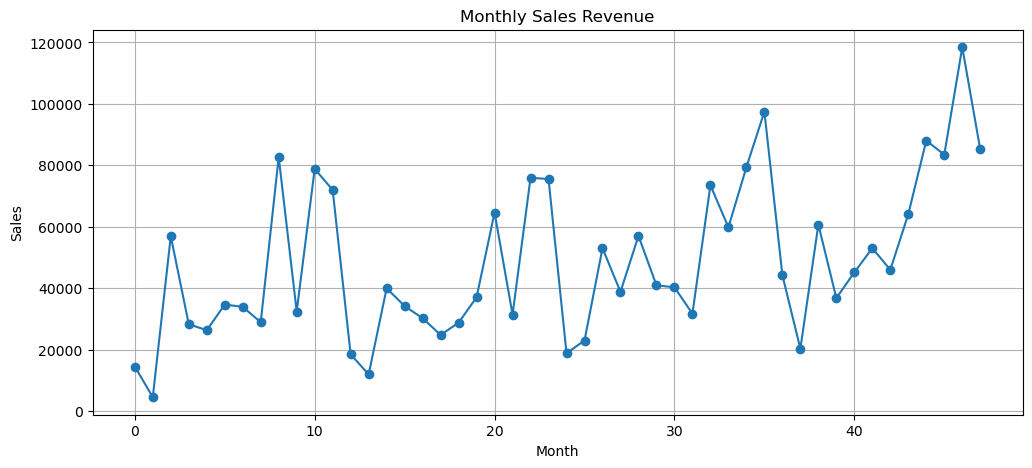

In [26]:
import matplotlib.pyplot as plt

monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly['Sales'], marker='o')

plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)
plt.show()

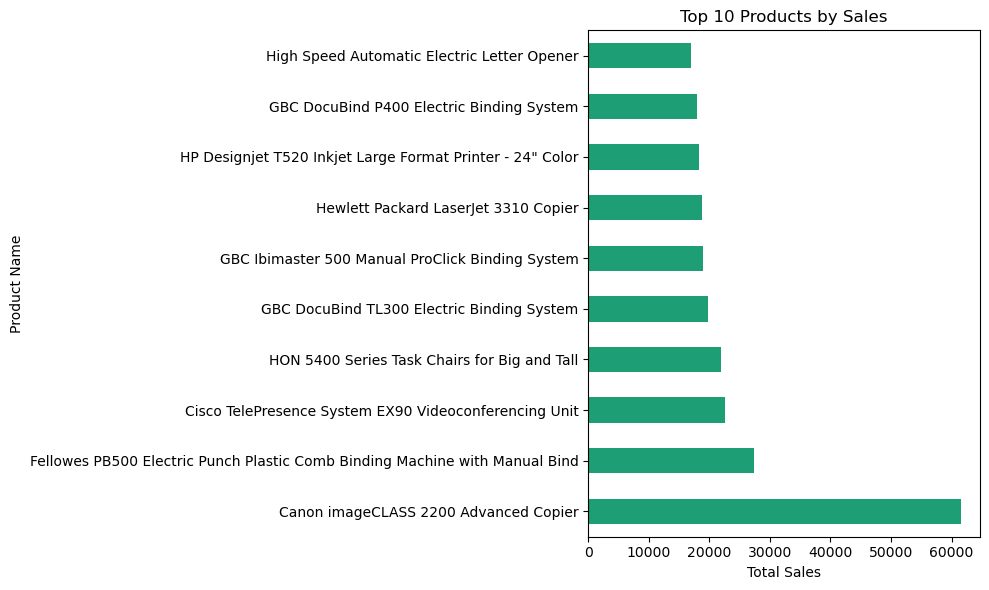

In [27]:
top_products = df.groupby('Product Name')['Sales'].sum()
top_products = top_products.sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(10,6), color='#1D9E75')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

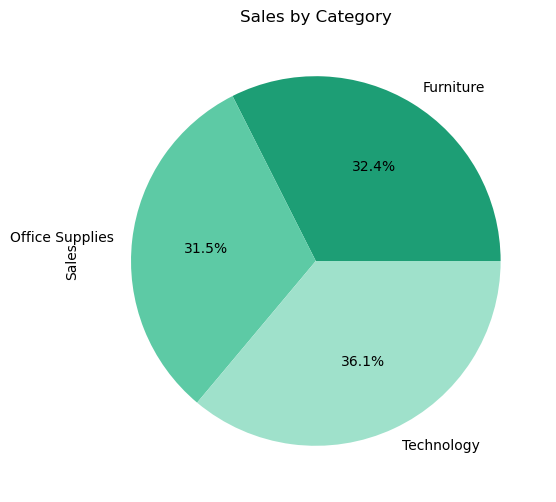

In [29]:
cat_sales = df.groupby('Category')['Sales'].sum()
cat_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6),
               colors=['#1D9E75','#5DCAA5','#9FE1CB'])
plt.title('Sales by Category')
plt.show()

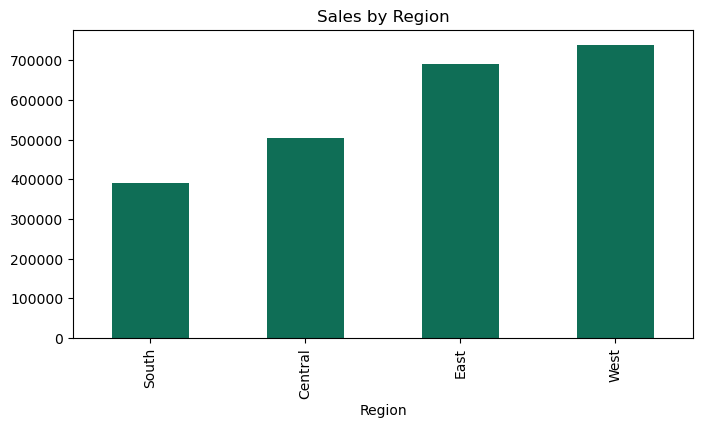

In [30]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
region_sales.plot(kind='bar', figsize=(8,4), color='#0F6E56')
plt.title('Sales by Region')
plt.show()